In [ ]:
# Tự nạp lại raw_feature.py mỗi khi sửa, không cần restart kernel
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from raw_feature import compute_feature

In [2]:
# Load split-index, dựng src/dest, lấy TRAN train (quyết định cột chỉ trên train)
dtype = {"From Bank": str, "Account": str, "To Bank": str, "Account.1": str}
df = pd.read_csv("dataset_high/HI-Small_Trans_split_index.csv", dtype=dtype)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["src"]  = df["From Bank"] + " | " + df["Account"]
df["dest"] = df["To Bank"]   + " | " + df["Account.1"]

train = df[df["split"] == "train"]
feat = compute_feature(train)
print("feat shape:", feat.shape)

feat shape: (512713, 20)


In [ ]:
# Bảng skew: thô vs sau log1p
ratio_cols = ["cross_bank_ratio", "cross_currency_ratio", "round_amount_ratio"]  # đã [0,1], bỏ qua
special    = ["net_flow"]                                                        # có âm, xử lý riêng
cand   = [c for c in feat.columns if c not in ratio_cols + special]              #cand là cột chứa cột cần xử lý
nonneg = [c for c in cand if feat[c].min() >= 0]                                 # log1p chỉ hợp lệ khi >= 0

report = pd.DataFrame({
    "min":        feat[cand].min(),
    "skew_raw":   feat[cand].skew(),
    "skew_log1p": np.log1p(feat[nonneg]).skew(),
}).sort_values("skew_raw", ascending=False)

report.round(2)

,min,skew_raw,skew_log1p
num_send,0.0,495.55,1.33
out_degree,0.0,492.93,1.20
tx_per_day,0.4,471.26,0.50
std_send,0.0,359.41,0.51
mean_send,0.0,325.98,-0.07
tong_gui,0.0,302.53,-0.05
tong_nhan,0.0,240.95,-0.29
std_receive,0.0,232.18,0.30
mean_receive,0.0,178.71,-0.22
num_bank_out,0.0,94.62,1.05


In [4]:
# Đề xuất cột log1p (lệch phải mạnh + không âm). Vẫn nên nhìn skew_log1p để loại cột bị kéo quá đà.
log1p_cols = report.index[(report["skew_raw"] > 1) & (report["min"] >= 0)].tolist()
print("Đề xuất log1p_cols:")
for c in log1p_cols:
    print(f"  {c:18s} skew_raw={report.loc[c,'skew_raw']:.2f} -> skew_log1p={report.loc[c,'skew_log1p']:.2f}")

Đề xuất log1p_cols:
  num_send           skew_raw=495.55 -> skew_log1p=1.33
  out_degree         skew_raw=492.93 -> skew_log1p=1.20
  tx_per_day         skew_raw=471.26 -> skew_log1p=0.50
  std_send           skew_raw=359.41 -> skew_log1p=0.51
  mean_send          skew_raw=325.98 -> skew_log1p=-0.07
  tong_gui           skew_raw=302.53 -> skew_log1p=-0.05
  tong_nhan          skew_raw=240.95 -> skew_log1p=-0.29
  std_receive        skew_raw=232.18 -> skew_log1p=0.30
  mean_receive       skew_raw=178.71 -> skew_log1p=-0.22
  num_bank_out       skew_raw=94.62 -> skew_log1p=1.05
  num_bank_in        skew_raw=45.40 -> skew_log1p=-0.11
  in_degree          skew_raw=45.27 -> skew_log1p=-0.06
  num_receive        skew_raw=2.40 -> skew_log1p=0.28
  active_day         skew_raw=1.26 -> skew_log1p=1.17


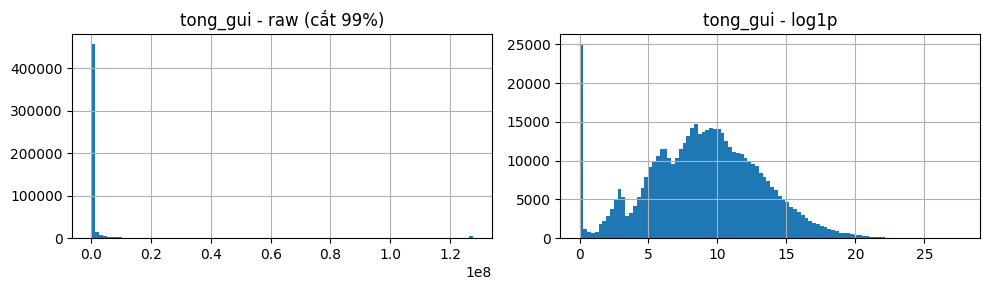

In [5]:
# Nhìn phân phối 1 cột mẫu trước/sau log1p (đổi `col` để xem cột khác)
col = "tong_gui"
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
feat[col].clip(upper=feat[col].quantile(0.99)).hist(bins=100, ax=ax[0]); ax[0].set_title(f"{col} - raw (cắt 99%)")
np.log1p(feat[col]).hist(bins=100, ax=ax[1]);                            ax[1].set_title(f"{col} - log1p")
plt.tight_layout(); plt.show()